In [1]:
import numpy as np
import pandas as pd
import math
from scipy.integrate import quad
from scipy.linalg import solve
from tqdm import tqdm

# ── Parameters ────────────────────────────────────────────────────────────────
r             = 0.1
ACTION_START  = pd.Timestamp("2024-01-01")
ACTION_END    = pd.Timestamp("2025-12-31")
N_ACTION_DAYS = (ACTION_END - ACTION_START).days + 1  # 731

# ── Data ──────────────────────────────────────────────────────────────────────
F_C_full        = pd.read_csv("../data/THE_data_original.csv")
seasonal_params = pd.read_csv("../data/seasonal_params.csv")

a1_hat = float(seasonal_params["a1_hat"].iloc[0])
a2_hat = float(seasonal_params["a2_hat"].iloc[0])

for col in ["delivery_start", "delivery_end", "trading_date"]:
    F_C_full[col] = (
        pd.to_datetime(F_C_full[col], utc=True)
        .dt.tz_convert(None)
        .dt.normalize()
    )

def parse_contract(row):
    ct, c = row["contract_type"], row["contract"]
    if ct == "month":
        return pd.to_datetime(f"01 {c}", format="%d %b %Y")
    if ct == "quarter":
        year, q = int(c[:4]), int(c[6])
        return pd.Timestamp(year=year, month=1 + 3*(q - 1), day=1)
    if ct == "year":
        return pd.Timestamp(year=int(c), month=1, day=1)
    raise ValueError(f"Unknown contract_type={ct!r}")

F_C_full["contract"] = F_C_full.apply(parse_contract, axis=1)
F_C_full = F_C_full.sort_values(["trading_date", "delivery_start"]).reset_index(drop=True)

def get_contracts_for_date(trading_date: pd.Timestamp) -> pd.DataFrame:
    sub = F_C_full[F_C_full["trading_date"] == trading_date]
    month_starts = set(sub.loc[sub["contract_type"] == "month", "delivery_start"])
    keep = (sub["contract_type"] == "month") | (
           (sub["contract_type"] == "quarter") & ~sub["delivery_start"].isin(month_starts))
    return sub[keep].sort_values("delivery_start").reset_index(drop=True)

# ── Seasonal component ────────────────────────────────────────────────────────
_WEEKEND_SPREAD = -0.35   # EUR/MWh
_WEEKDAY_SHIFT  = -_WEEKEND_SPREAD * (2.0 / 7.0)
_WEEKEND_SHIFT  = _WEEKDAY_SHIFT + _WEEKEND_SPREAD

def s(tau, origin: pd.Timestamp):
    """
    Seasonal price component at year-fraction tau measured from origin.
    Annual sinusoidal term plus a flat weekday/weekend spread.
    Uses integer modular arithmetic to avoid pandas overhead on scalar calls.
    """
    tau      = np.atleast_1d(np.asarray(tau, dtype=float))
    days     = np.floor(tau * 365.0 + 1e-12).astype(int)
    weekdays = (origin.weekday() + days) % 7
    spread   = np.where(weekdays >= 5, _WEEKEND_SHIFT, _WEEKDAY_SHIFT).astype(float)
    result   = np.exp(a1_hat * np.sin(2*np.pi*tau) + a2_hat * np.cos(2*np.pi*tau)) + spread
    return float(result[0]) if result.size == 1 else result

# ── Forward curve helpers ─────────────────────────────────────────────────────
def _w(u: float, T_s: float, T_e: float) -> float:
    """Normalised PV weight: integrates to 1 over [T_s, T_e]."""
    return np.exp(-r * u) / ((np.exp(-r * T_s) - np.exp(-r * T_e)) / r)

def _phi(tau: float) -> tuple:
    """C0, C1, C2 basis vectors at tau for a degree-4 polynomial."""
    return (
        np.array([tau**4, tau**3, tau**2, tau, 1.0]),
        np.array([4*tau**3, 3*tau**2, 2*tau, 1.0, 0.0]),
        np.array([12*tau**2, 6*tau, 2.0, 0.0, 0.0]),
    )

def _day_breakpoints(T_s: float, T_e: float) -> list:
    """Interior day-boundary points in (T_s, T_e) — discontinuities of s(u)."""
    lo = math.ceil(T_s * 365.0 + 1e-9)
    hi = math.floor(T_e * 365.0 - 1e-9)
    return [k / 365.0 for k in range(lo, hi + 1)]

# ── Forward curve construction ────────────────────────────────────────────────
def construct_forward_curve(trading_date: pd.Timestamp) -> tuple:
    F_C = get_contracts_for_date(trading_date).copy()
    F_C["T_s"] = (F_C["delivery_start"] - trading_date).dt.days / 365.0
    F_C["T_e"] = (F_C["delivery_end"]   - trading_date).dt.days / 365.0

    t     = np.r_[F_C["T_s"].to_numpy(), F_C["T_e"].iloc[-1]]
    n     = len(t) - 1
    Delta = np.diff(t)

    # Hessian (smoothness penalty on epsilon'')
    H = np.zeros((5*n, 5*n))
    for j in range(n):
        Dj = Delta[j]; sl = slice(5*j, 5*j+5)
        H[sl, sl] = np.array([
            [(144/5)*Dj**5, 18*Dj**4, 8*Dj**3, 0, 0],
            [18*Dj**4,      12*Dj**3, 6*Dj**2, 0, 0],
            [8*Dj**3,        6*Dj**2, 4*Dj,    0, 0],
            [0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0],
        ])

    # Constraint matrix
    num_constraints = 3*(n - 1) + n + 2
    A = np.zeros((num_constraints, 5*n))
    b = np.zeros(num_constraints)
    row = 0

    # C0/C1/C2 continuity at interior knots
    for j in range(n - 1):
        p0, p1, p2 = _phi(t[j + 1])
        sl, sr = slice(5*j, 5*j+5), slice(5*j+5, 5*j+10)
        A[row,   sl] = -p0;  A[row,   sr] = p0
        A[row+1, sl] = -p1;  A[row+1, sr] = p1
        A[row+2, sl] = -p2;  A[row+2, sr] = p2
        row += 3

    # Contract-consistency: weighted average of epsilon matches price minus seasonal shift
    for i in range(n):
        T_s, T_e = t[i], t[i + 1]
        bpts = _day_breakpoints(T_s, T_e)
        kw   = {"points": bpts, "limit": len(bpts) + 50} if bpts else {}
        A[row, 5*i:5*i+5] = [
            quad(lambda u, p=p: _w(u, T_s, T_e) * u**p, T_s, T_e)[0]
            for p in range(4, -1, -1)
        ]
        b[row] = (
            float(F_C["price"].iloc[i])
            - quad(lambda u: _w(u, T_s, T_e) * s(u, trading_date), T_s, T_e, **kw)[0]
        )
        row += 1

    # Boundary: epsilon'(t_n) = 0
    _, p1_n, _ = _phi(t[n])
    A[row, 5*(n-1):5*n] = p1_n; row += 1

    # Initial condition: pin epsilon at the first knot
    p0_0, _, _ = _phi(t[0])
    A[row, :5] = p0_0
    b[row]     = float(F_C["price"].iloc[0]) - s(t[0], trading_date)

    # KKT solve
    KKT = np.block([[2*H, A.T], [A, np.zeros((num_constraints, num_constraints))]])
    x   = solve(KKT, np.r_[np.zeros(5*n), b], assume_a="sym")[:5*n]

    # Evaluate on daily grid (vectorised per segment using np.polyval)
    n_days  = int(round(F_C["T_e"].iloc[-1] * 365))
    t_eval  = np.arange(n_days + 1) / 365.0
    j_idx   = np.clip(np.searchsorted(t, t_eval, side="right") - 1, 0, n - 1)
    epsilon = np.empty(len(t_eval))
    for j in range(n):
        mask = j_idx == j
        if mask.any():
            epsilon[mask] = np.polyval(x[5*j:5*j+5], t_eval[mask])

    return (
        pd.date_range(start=trading_date, periods=len(t_eval), freq="D"),
        epsilon + s(t_eval, trading_date),
    )

# ── Build forward-price surface ───────────────────────────────────────────────
action_dates      = pd.date_range(ACTION_START, ACTION_END, freq="D")
all_trading_dates = pd.to_datetime(np.sort(F_C_full["trading_date"].unique()))
# Keep only dates within the action period, plus the last one before it
_pre = all_trading_dates[all_trading_dates < ACTION_START]
all_trading_dates = all_trading_dates[
    (all_trading_dates >= (_pre[-1] if len(_pre) else ACTION_START)) &
    (all_trading_dates <= ACTION_END)
]
del _pre

print("Building forward curve cache ...")
curve_cache: dict = {}
for td in tqdm(all_trading_dates):
    fwd_dates, fwd_prices = construct_forward_curve(td)
    curve_cache[td] = dict(zip(fwd_dates.normalize(), fwd_prices.tolist()))

# surface[i, j] = forward price for action day j seen from action day i
# Only the upper triangle (j >= i) is populated and used by the DP.
print("Filling forward-price surface ...")
surface = np.full((N_ACTION_DAYS, N_ACTION_DAYS), np.nan)

for i, action_day in enumerate(tqdm(action_dates)):
    candidates = all_trading_dates[all_trading_dates <= action_day]
    if len(candidates) == 0:
        raise ValueError(f"No trading date on or before {action_day.date()}")
    fwd_dict = curve_cache[candidates[-1]]
    for j in range(i, N_ACTION_DAYS):
        surface[i, j] = fwd_dict.get(action_dates[j], np.nan)

Building forward curve cache ...


100%|██████████| 503/503 [01:23<00:00,  6.01it/s]


Filling forward-price surface ...


100%|██████████| 731/731 [00:00<00:00, 1542.23it/s]


In [2]:
import numba as nb

# ============================================================
# MODEL PARAMETERS
# ============================================================
vmin, vmax       = 0.0, 250_000.0
v0               = 100_000.0
vT_target        = 100_000.0
inj_max          = 2_500.0
wdr_max          = 7_500.0
alpha            = 250.0
r_annual         = 0.1
terminal_penalty = np.inf
dt               = 1.0 / 365.0
disc             = np.exp(-r_annual * dt)

v_grid = np.arange(vmin, vmax + alpha, alpha, dtype=np.float64)
N_grid = v_grid.size

def index_of(v: float) -> int:
    return int(round((v - vmin) / alpha))

n0 = index_of(v0)
nT = index_of(vT_target)

# ── Precompute feasible moves ─────────────────────────────────────────────────
K_max = 0
for ni in range(N_grid):
    v      = v_grid[ni]
    dv_min = max(vmin - v, -wdr_max)
    dv_max = min(vmax - v,  inj_max)
    k_min  = int(np.ceil(dv_min  / alpha))
    k_max  = int(np.floor(dv_max / alpha))
    K_max  = max(K_max, k_max - k_min + 1)

next_idx_mat = np.full((N_grid, K_max), -1,  dtype=np.int32)
dv_mat       = np.zeros((N_grid, K_max),      dtype=np.float64)
K_len        = np.zeros(N_grid,               dtype=np.int32)

for ni in range(N_grid):
    v      = v_grid[ni]
    dv_min = max(vmin - v, -wdr_max)
    dv_max = min(vmax - v,  inj_max)
    k_min  = int(np.ceil(dv_min  / alpha))
    k_max  = int(np.floor(dv_max / alpha))
    idxs   = ni + np.arange(k_min, k_max + 1, dtype=np.int32)
    idxs   = idxs[(idxs >= 0) & (idxs < N_grid)]
    k      = idxs.size
    K_len[ni]            = k
    next_idx_mat[ni, :k] = idxs
    dv_mat[ni, :k]       = v_grid[idxs] - v


@nb.njit(fastmath=True)
def bellman_step(Y_current, pi_row, S_t, Y_next, disc,
                 next_idx_mat, dv_mat, K_len):
    Nloc = next_idx_mat.shape[0]
    for ni in range(Nloc):
        klen = K_len[ni]
        if klen == 0:
            Y_current[ni] = -np.inf
            pi_row[ni]    = -1
            continue
        best_val  = -np.inf
        best_next = -1
        for k in range(klen):
            nxt  = next_idx_mat[ni, k]
            cand = (-S_t * dv_mat[ni, k]) + disc * Y_next[nxt]
            if cand > best_val:
                best_val  = cand
                best_next = nxt
        Y_current[ni] = best_val
        pi_row[ni]    = best_next


# ── Rolling intrinsic DP ──────────────────────────────────────────────────────
current_volume = v0
daily_pnl      = np.zeros(N_ACTION_DAYS, dtype=np.float64)
decisions      = np.zeros(N_ACTION_DAYS, dtype=np.float64)
volume_path    = np.zeros(N_ACTION_DAYS + 1, dtype=np.float64)
volume_path[0] = current_volume

pi_first = np.full(N_grid, -1, dtype=np.int32)
pi_dummy = np.full(N_grid, -1, dtype=np.int32)

print("Running rolling intrinsic DP...")
for i in tqdm(range(N_ACTION_DAYS)):
    remaining_prices = surface[i, i:]
    T_rem = len(remaining_prices)

    Y_next     = np.full(N_grid, -terminal_penalty, dtype=np.float64)
    Y_next[nT] = 0.0
    Y_current  = np.empty(N_grid, dtype=np.float64)

    for t_step in range(T_rem - 1, -1, -1):
        S_t    = float(remaining_prices[t_step])
        pi_row = pi_first if t_step == 0 else pi_dummy
        bellman_step(
            Y_current, pi_row, S_t, Y_next, disc,
            next_idx_mat, dv_mat, K_len
        )
        Y_next, Y_current = Y_current, Y_next

    ni_current = index_of(current_volume)
    ni_next    = int(pi_first[ni_current])

    if ni_next == -1:
        raise ValueError(
            f"No feasible action on day {i} ({action_dates[i].date()}) "
            f"from volume {current_volume}"
        )

    dv             = v_grid[ni_next] - current_volume
    spot_price     = float(surface[i, i])
    cash_flow      = -spot_price * dv

    decisions[i]       = dv
    daily_pnl[i]       = cash_flow
    current_volume     = v_grid[ni_next]
    volume_path[i + 1] = current_volume

total_value = float(np.sum(daily_pnl))
print(f"\nRolling intrinsic value : {total_value:,.2f}")
print(f"Final volume            : {current_volume:,.0f}  (target: {vT_target:,.0f})")

# ── Save results ──────────────────────────────────────────────────────────────
results = pd.DataFrame({
    "date":          action_dates,
    "forward_price": surface[np.arange(N_ACTION_DAYS), np.arange(N_ACTION_DAYS)],
    "decision_dv":   decisions,
    "daily_pnl":     daily_pnl,
    "volume":        volume_path[:-1],
})
results.to_csv("../data/rolling_intrinsic_results.csv", index=False)

Running rolling intrinsic DP...


100%|██████████| 731/731 [00:08<00:00, 91.31it/s] 


Rolling intrinsic value : 3,258,376.15
Final volume            : 100,000  (target: 100,000)


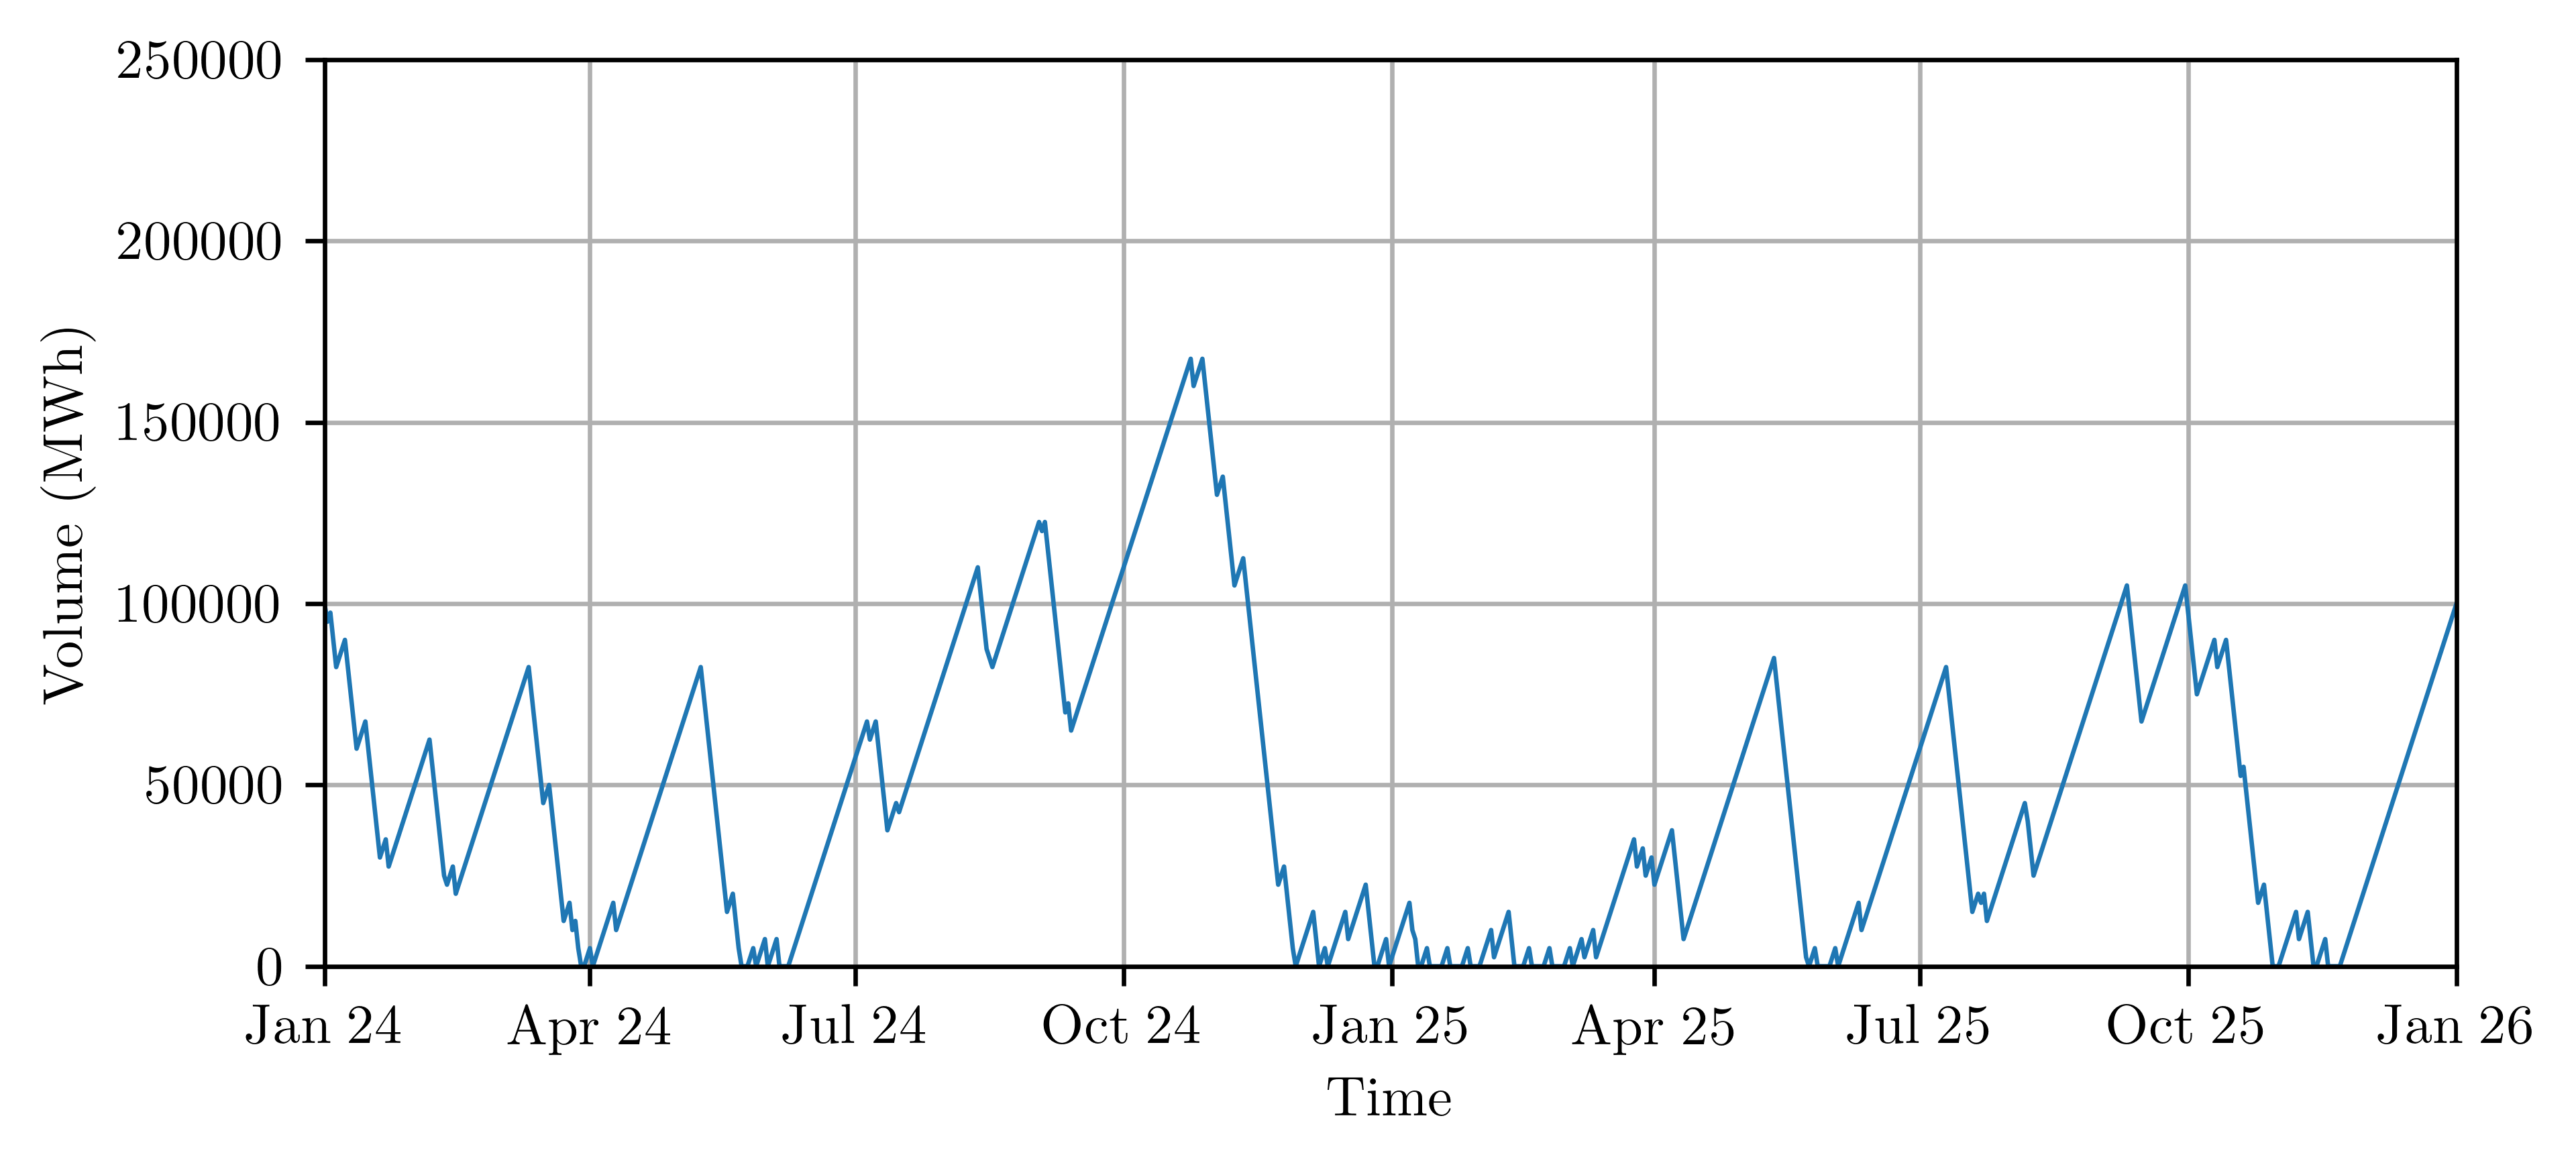

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

# ----------------------------
# Load results
# ----------------------------
results = pd.read_csv("../data/rolling_intrinsic_results.csv")
results["date"] = pd.to_datetime(results["date"])

# volume_path has N_ACTION_DAYS entries corresponding to the volume at the
# START of each action day (before the trade on that day is executed).
# We append the final volume after the last trade to complete the path.
volume_path_plot = np.append(results["volume"].to_numpy(),
                             results["volume"].iloc[-1] + results["decision_dv"].iloc[-1])

ACTION_START = pd.Timestamp("2024-01-01")
ACTION_END   = pd.Timestamp("2025-12-31")
dates = pd.date_range(start=ACTION_START, end=ACTION_END + pd.Timedelta(days=1), freq="D")

fig, ax = plt.subplots(figsize=(6.5, 3), dpi=600)

ax.plot(dates, volume_path_plot, linewidth=0.8)

# X ticks every 3 months, starting at Jan 2024
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))

# Y ticks
ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(50000))

ax.set_ylim(0, 250000)

ax.set_xlabel("Time")
ax.set_ylabel("Volume (MWh)")
ax.set_xlim(dates[0], dates[-1])
ax.grid(True)

fig.tight_layout()
plt.savefig("../../fig/Plots/rolling_intrinsic_valuation.png")
plt.show()